In [65]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import random as rnd

In [66]:
# ==========================================
# CONFIGURACIÓN DE SEMILLAS (VERIFICACIÓN)
# ==========================================
# Garantiza la reproducibilidad exacta de las corridas experimentales

rnd.seed(101)
np.random.seed(101)

# Parámetros de Entrada del Sistema

TIEMPO_SIMULACION = 480  # Jornada operativa de 8 horas (en minutos)
CATEGORIAS = ['Rápido', 'Normal', 'Lento', 'Muy Lento']
PROB_TEORICAS = [0.25, 0.20, 0.275, 0.275] # 25% Rápido, 20% Normal, 55% Restante balanceado

MEDIAS_SERVICIO = {'Rápido': 1.0, 'Normal': 3.0, 'Lento': 4.0, 'Muy Lento': 6.0}
MEDIAS_LLEGADA = {'Rápido': 3.0, 'Normal': 3.0, 'Lento': 5.0, 'Muy Lento': 7.0}

# Cálculo Analítico de la Tasa Global de Llegada (Lambda total)
lambda_total = sum(p / MEDIAS_LLEGADA[cat] for cat, p in zip(CATEGORIAS, PROB_TEORICAS))
media_llegada_global = 1.0 / lambda_total

def generar_tiempo_exponencial(media):
    """Genera tiempos aleatorios exponenciales asegurando la restricción de no negatividad."""
    u = rnd.random()
    tiempo = -media * np.log(u)
    return max(0.0, tiempo)

def calcular_intervalo_confianza(datos, confianza=0.95):
    """Calcula el intervalo de confianza t-student para un conjunto de observaciones."""
    n = len(datos)
    if n < 2: return 0.0
    sem = stats.sem(datos)
    return sem * stats.t.ppf((1 + confianza) / 2., n - 1)

In [67]:
# ===================================================
# MOTOR DE SIMULACIÓN 1: ESCENARIO ACTUAL (3x M/M/1)
# ===================================================

def simular_escenario_actual(tiempo_max=480):
    cajeros = {0: [], 1: [], 2: []}
    tiempos_espera = {0: [], 1: [], 2: []}
    tipos_atendidos = {0: [], 1: [], 2: []}
    tiempos_ocupados = {0: 0.0, 1: 0.0, 2: 0.0}

    reloj = 0.0
    proxima_llegada = generar_tiempo_exponencial(media_llegada_global)
    fin_servicio = [float('inf'), float('inf'), float('inf')]
    colas = [0, 0, 0]
    registro_colas = {0: [], 1: [], 2: []}

    evolucion_media = []
    lista_todos_ta = []

    while reloj < tiempo_max or any(c > 0 for c in colas):
        proximo_evento = min(proxima_llegada, min(fin_servicio))

        if proximo_evento == proxima_llegada and reloj < tiempo_max:
            # EVENTO: LLEGADA GLOBAL DE UN VEHÍCULO
            reloj = proxima_llegada
            tipo_u = np.random.choice(CATEGORIAS, p=PROB_TEORICAS)

            # El conductor selecciona de forma independiente el cajero con la cola más corta
            cajero_sel = np.argmin(colas)
            colas[cajero_sel] += 1
            registro_colas[cajero_sel].append((reloj, tipo_u))

            proxima_llegada = reloj + generar_tiempo_exponencial(media_llegada_global)

            if colas[cajero_sel] == 1:
                t_ll, t_u = registro_colas[cajero_sel].pop(0)
                tiempos_espera[cajero_sel].append(0.0)
                t_serv = generar_tiempo_exponencial(MEDIAS_SERVICIO[t_u])
                fin_servicio[cajero_sel] = reloj + t_serv
                cajeros[cajero_sel].append(t_serv)
                tipos_atendidos[cajero_sel].append(t_u)
                tiempos_ocupados[cajero_sel] += t_serv

                lista_todos_ta.append(t_serv)
                evolucion_media.append(np.mean(lista_todos_ta))
        else:
            # EVENTO: FIN DE SERVICIO EN UN SERVIDOR
            cajero_sel = np.argmin(fin_servicio)
            reloj = fin_servicio[cajero_sel]
            colas[cajero_sel] -= 1
            fin_servicio[cajero_sel] = float('inf')

            if colas[cajero_sel] > 0:
                t_ll, t_u = registro_colas[cajero_sel].pop(0)
                tiempos_espera[cajero_sel].append(reloj - t_ll)
                t_serv = generar_tiempo_exponencial(MEDIAS_SERVICIO[t_u])
                fin_servicio[cajero_sel] = reloj + t_serv
                cajeros[cajero_sel].append(t_serv)
                tipos_atendidos[cajero_sel].append(t_u)
                tiempos_ocupados[cajero_sel] += t_serv

                lista_todos_ta.append(t_serv)
                evolucion_media.append(np.mean(lista_todos_ta))

        if reloj >= tiempo_max:
            proxima_llegada = float('inf')

    return cajeros, tiempos_espera, tipos_atendidos, tiempos_ocupados, evolucion_media

In [68]:
# ===================================================
# MOTOR DE SIMULACIÓN 2: ESCENARIO PROPUESTO (M/M/3)
# ===================================================
def simular_escenario_mejora(tiempo_max=480):
    tiempos_atencion = []
    tiempos_espera = []
    tiempos_ocupados = [0.0, 0.0, 0.0]

    reloj = 0.0
    proxima_llegada = generar_tiempo_exponencial(media_llegada_global)
    fin_servicio = [float('inf'), float('inf'), float('inf')]
    fila_unica = []

    while reloj < tiempo_max or len(fila_unica) > 0 or any(f != float('inf') for f in fin_servicio):
        proximo_evento = min(proxima_llegada, min(fin_servicio))

        if proximo_evento == proxima_llegada and reloj < tiempo_max:
            reloj = proxima_llegada
            tipo_u = np.random.choice(CATEGORIAS, p=PROB_TEORICAS)
            fila_unica.append((reloj, tipo_u))
            proxima_llegada = reloj + generar_tiempo_exponencial(media_llegada_global)

            for idx in range(3):
                if fin_servicio[idx] == float('inf') and len(fila_unica) > 0:
                    t_ll, t_u = fila_unica.pop(0)
                    tiempos_espera.append(0.0)
                    t_serv = generar_tiempo_exponencial(MEDIAS_SERVICIO[t_u])
                    fin_servicio[idx] = reloj + t_serv
                    tiempos_atencion.append(t_serv)
                    tiempos_ocupados[idx] += t_serv
                    break
        else:
            idx_serv = np.argmin(fin_servicio)
            reloj = fin_servicio[idx_serv]
            fin_servicio[idx_serv] = float('inf')

            if len(fila_unica) > 0:
                t_ll, t_u = fila_unica.pop(0)
                tiempos_espera.append(reloj - t_ll)
                t_serv = generar_tiempo_exponencial(MEDIAS_SERVICIO[t_u])
                fin_servicio[idx_serv] = reloj + t_serv
                tiempos_atencion.append(t_serv)
                tiempos_ocupados[idx_serv] += t_serv

        if reloj >= tiempo_max:
            proxima_llegada = float('inf')

    return tiempos_atencion, tiempos_espera, tiempos_ocupados

In [69]:
# --- EJECUCIÓN DE EXPERIMENTOS ---
cajeros_act, t_espera_act, tipos_act, t_ocu_act, ev_media = simular_escenario_actual()
ta_mej, te_mej, toc_mej = simular_escenario_mejora()

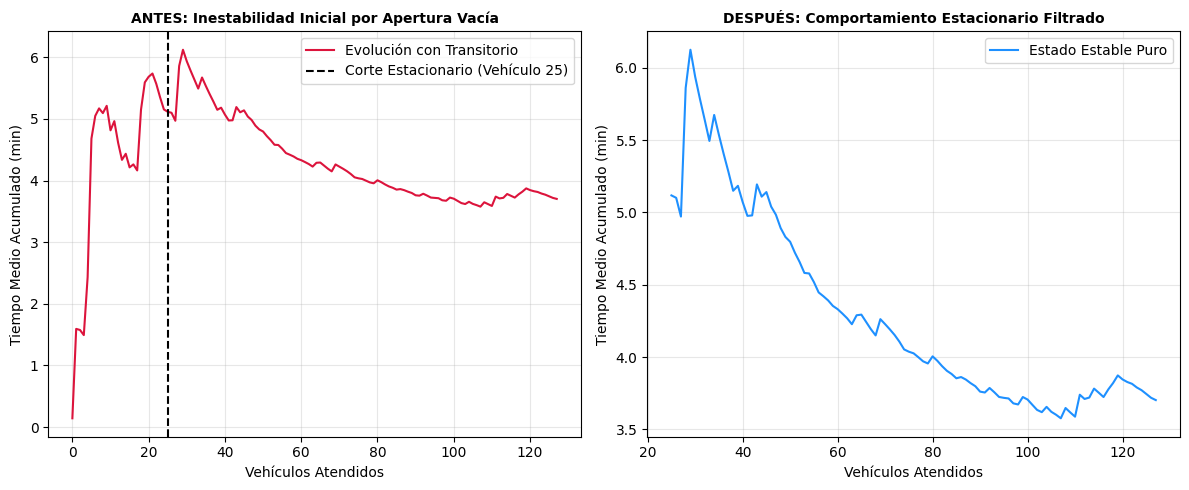

In [70]:
# ==========================================
# GENERACIÓN DE ENTREGABLES GRÁFICOS
# ==========================================

# Gráfica 1: Justificación Científica de la Eliminación del Transitorio (Antes vs Después)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(ev_media, color='crimson', label='Evolución con Transitorio')
plt.axvline(x=25, color='black', linestyle='--', label='Corte Estacionario (Vehículo 25)')
plt.title('ANTES: Inestabilidad Inicial por Apertura Vacía', fontsize=10, fontweight='bold')
plt.xlabel('Vehículos Atendidos')
plt.ylabel('Tiempo Medio Acumulado (min)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(25, len(ev_media)), ev_media[25:], color='dodgerblue', label='Estado Estable Puro')
plt.title('DESPUÉS: Comportamiento Estacionario Filtrado', fontsize=10, fontweight='bold')
plt.xlabel('Vehículos Atendidos')
plt.ylabel('Tiempo Medio Acumulado (min)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

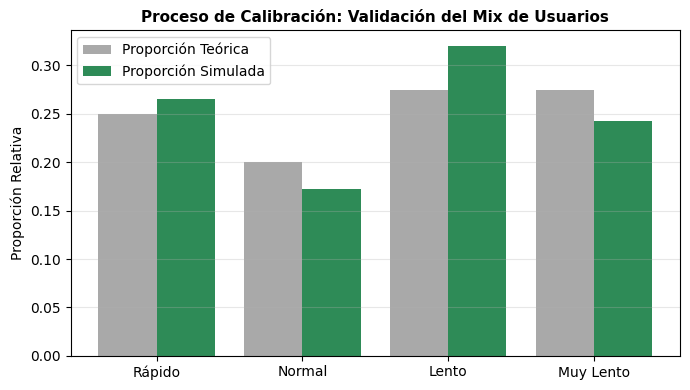

In [71]:
# Gráfica 2: Calibración y Verificación Teórica vs Muestral de Población
todos_usuarios = []
for c in tipos_act.values(): todos_usuarios.extend(c)
conteo_sim = [todos_usuarios.count(cat)/len(todos_usuarios) for cat in CATEGORIAS]

plt.figure(figsize=(7, 4))
x = np.arange(len(CATEGORIAS))
plt.bar(x - 0.2, PROB_TEORICAS, 0.4, label='Proporción Teórica', color='darkgray')
plt.bar(x + 0.2, conteo_sim, 0.4, label='Proporción Simulada', color='seagreen')
plt.xticks(x, CATEGORIAS)
plt.title('Proceso de Calibración: Validación del Mix de Usuarios', fontsize=11, fontweight='bold')
plt.ylabel('Proporción Relativa')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
# ==========================================
# DESPLIEGUE DE REPORTES EN CONSOLA
# ==========================================
print("\n" + "="*75)
print(" METRICAS AVANZADAS POR SERVIDOR (ESCENARIO ACTUAL 3x M/M/1)")
print("="*75)
for i in range(3):
    data = cajeros_act[i]
    ic = calcular_intervalo_confianza(data)
    print(f"Cajero {i+1} -> Obs: {len(data)} | Media: {np.mean(data):.2f} min | DevStd: {np.std(data):.2f} | "
          f"Mín: {np.min(data):.2f} | Máx: {np.max(data):.2f} | IC 95%: [{np.mean(data)-ic:.2f} , {np.mean(data)+ic:.2f}]")

print("\n" + "="*75)
print(" COMPARATIVA DE ESCENARIOS Y ANÁLISIS DE OPTIMIZACIÓN (PUNTO C)")
print("="*75)
wq_actual = np.mean([np.mean(t_espera_act[i]) for i in range(3)])
wq_propuesto = np.mean(te_mej)
print(f"(-) Tiempo Medio de Espera en Cola - Escenario Actual (3xM/M/1): {wq_actual:.2f} minutos")
print(f"(-) Tiempo Medio de Espera en Cola - Escenario Propuesto (M/M/3): {wq_propuesto:.2f} minutos")
print(f"(*) Reducción Neta del Tiempo de Espera en Fila: {((wq_actual - wq_propuesto) / wq_actual)*100:.1f}%")
print("="*75)


 METRICAS AVANZADAS POR SERVIDOR (ESCENARIO ACTUAL 3x M/M/1)
Cajero 1 -> Obs: 68 | Media: 3.61 min | DevStd: 4.67 | Mín: 0.02 | Máx: 30.75 | IC 95%: [2.47 , 4.75]
Cajero 2 -> Obs: 39 | Media: 3.73 min | DevStd: 5.46 | Mín: 0.07 | Máx: 22.94 | IC 95%: [1.94 , 5.52]
Cajero 3 -> Obs: 21 | Media: 3.95 min | DevStd: 3.91 | Mín: 0.40 | Máx: 13.77 | IC 95%: [2.13 , 5.78]

 COMPARATIVA DE ESCENARIOS Y ANÁLISIS DE OPTIMIZACIÓN (PUNTO C)
(-) Tiempo Medio de Espera en Cola - Escenario Actual (3xM/M/1): 0.13 minutos
(-) Tiempo Medio de Espera en Cola - Escenario Propuesto (M/M/3): 0.02 minutos
(*) Reducción Neta del Tiempo de Espera en Fila: 83.5%
